title post xgboost/optuna

✅ Loaded: 737 rows from 2024-01-02 to 2026-01-07
        date    return  sentiment
0 2024-01-02 -0.039506   0.854176
1 2024-01-03 -0.002874   0.854176
2 2024-01-04  0.012733   0.854176
3 2024-01-05  0.013160   0.854176
4 2024-01-06  0.000000   0.854176
✅ After feature engineering: 733 rows
✅ Train size: 585 | Test size: 147


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best Accuracy (CV): 0.6632
✅ Best Params: {'n_estimators': 281, 'max_depth': 7, 'learning_rate': 0.0001450486587761426, 'subsample': 0.8037724259507192, 'colsample_bytree': 0.5852620618436457, 'min_child_weight': 1, 'reg_alpha': 0.39001768308022033, 'reg_lambda': 0.530953226900921, 'gamma': 4.041986740582305}

📊 TEST SET RESULTS
   RMSE          : 0.026920
   MAE           : 0.019609
   Direction Acc : 66.7%

              precision    recall  f1-score   support

        Down       0.67      1.00      0.80        98
          Up       0.00      0.00      0.00        49

    accuracy                           0.67       147
   macro avg       0.33      0.50      0.40       147
weighted avg       0.44      0.67      0.53       147


       date  actual_return  predicted_return  actual_dir  predicted_dir  prob_up  direction_correct
2025-12-28       0.019047         -0.012026           1              0 0.340994              False
2025-12-29      -0.002455         -0.012016           0  

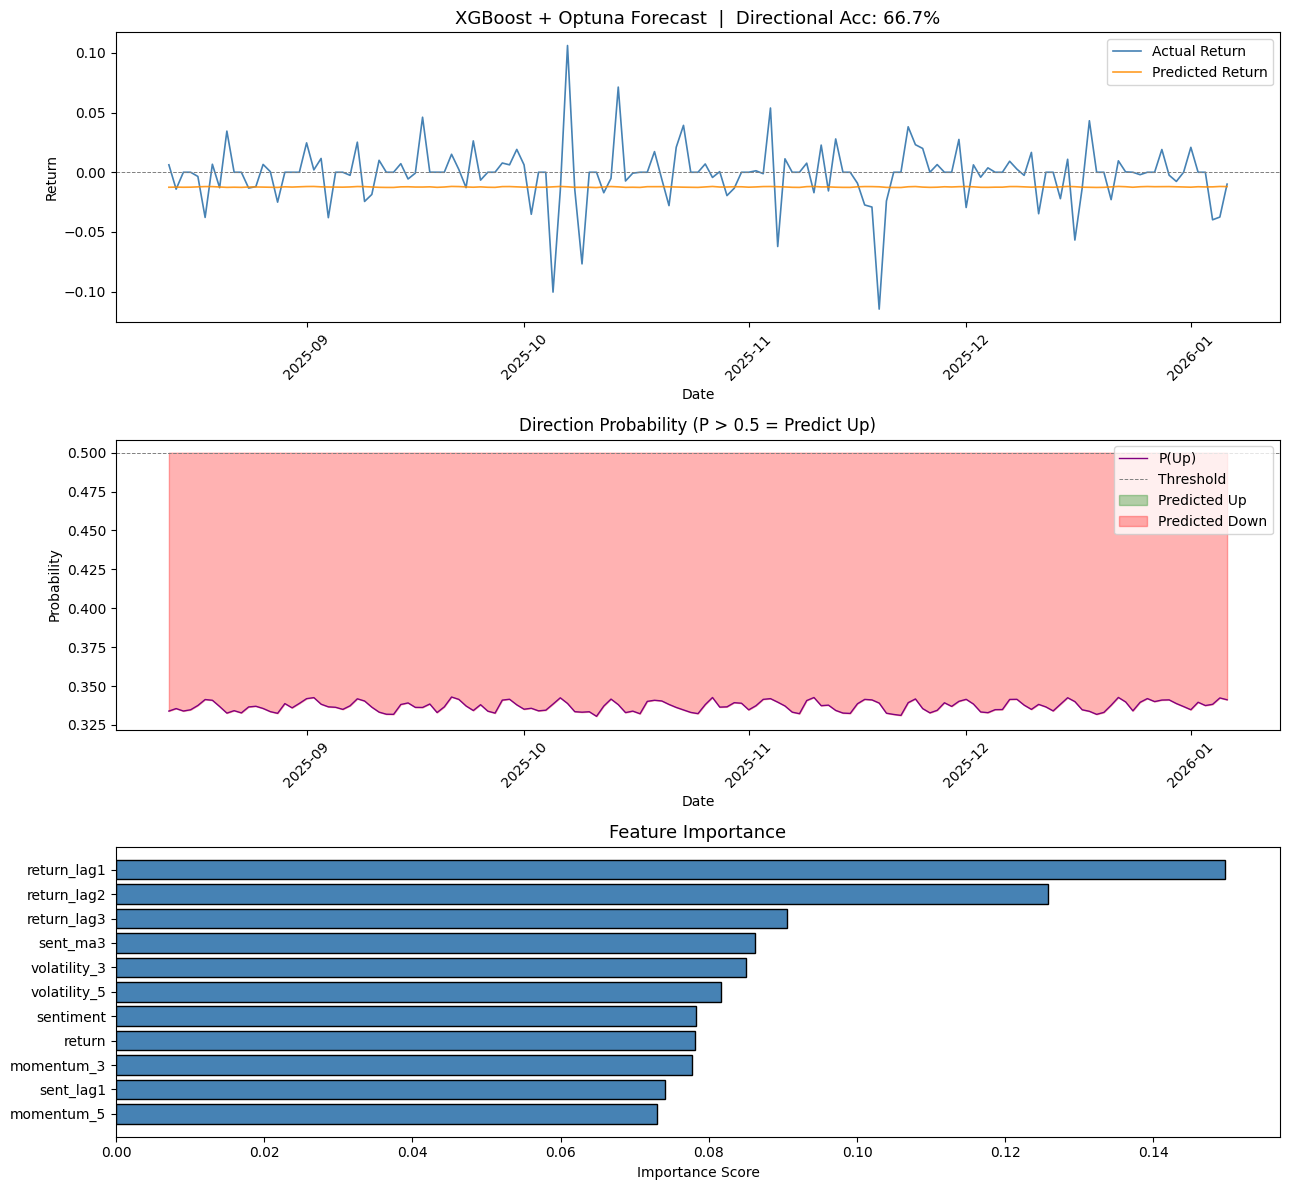

In [ ]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
!pip install optuna xgboost scikit-learn pandas numpy matplotlib openpyxl -q

# ============================================================
# IMPORTS
# ============================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv('/content/dataset_title_post_full.xlsx - Sheet1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✅ Loaded: {df.shape[0]} rows from {df['date'].min().date()} to {df['date'].max().date()}")
print(df.head())

# ============================================================
# FEATURE ENGINEERING
# ============================================================
df['return_lag1']  = df['return'].shift(1)
df['return_lag2']  = df['return'].shift(2)
df['return_lag3']  = df['return'].shift(3)

df['momentum_3']   = df['return'].rolling(3).sum()
df['momentum_5']   = df['return'].rolling(5).sum()

df['volatility_3'] = df['return'].rolling(3).std()
df['volatility_5'] = df['return'].rolling(5).std()

df['sent_lag1']    = df['sentiment'].shift(1)
df['sent_ma3']     = df['sentiment'].rolling(3).mean()

df = df.dropna().reset_index(drop=True)

print(f"✅ After feature engineering: {df.shape[0]} rows")

# ============================================================
# TARGET: next day's return & direction
# ============================================================
df['next_return'] = df['return'].shift(-1)
df = df.iloc[:-1].reset_index(drop=True)

dates = df['date']

FEATURES = [
    'return', 'sentiment',
    'return_lag1', 'return_lag2', 'return_lag3',
    'momentum_3',  'momentum_5',
    'volatility_3','volatility_5',
    'sent_lag1',   'sent_ma3'
]

X     = df[FEATURES].values
y_mag = df['next_return'].values

# Derive direction from actual returns (same as GA-LSTM)
dir_actual = (y_mag > 0).astype(int)

# ============================================================
# SCALE
# ============================================================
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# TRAIN/TEST SPLIT (80/20, time-ordered)
# ============================================================
split_idx = int(len(X_scaled) * 0.8)

X_train, X_test         = X_scaled[:split_idx], X_scaled[split_idx:]
y_mag_train, y_mag_test = y_mag[:split_idx],    y_mag[split_idx:]
dir_train,   dir_test   = dir_actual[:split_idx], dir_actual[split_idx:]
dates_test              = dates.values[split_idx:]

print(f"✅ Train size: {len(X_train)} | Test size: {len(X_test)}")

# ============================================================
# OPTUNA HYPERPARAMETER TUNING
# ============================================================
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-4, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': 42,
        'tree_method': 'hist',
        'device': 'cpu',
        'eval_metric': 'logloss'
    }

    kf = KFold(n_splits=5, shuffle=False)
    cv_scores = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val     = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val     = dir_train[tr_idx], dir_train[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict(X_val)
        cv_scores.append(accuracy_score(y_val, preds))

    return np.mean(cv_scores)

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best Accuracy (CV): {study.best_value:.4f}")
print(f"✅ Best Params: {study.best_params}")

# ============================================================
# TRAIN FINAL MODEL WITH BEST PARAMS
# ============================================================
best_params = study.best_params
best_params.update({
    'random_state': 42,
    'tree_method': 'hist',
    'device': 'cpu',
    'eval_metric': 'logloss'
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, dir_train, verbose=False)

# ============================================================
# PREDICT (same formula as GA-LSTM)
# ============================================================
dir_pred_prob = final_model.predict_proba(X_test)[:, 1]
dir_pred      = (dir_pred_prob > 0.5).astype(int)

mean_abs_return = np.mean(np.abs(y_mag_train))
confidence      = (dir_pred_prob - 0.5) * 2
y_pred_final    = confidence * mean_abs_return * 3

# ============================================================
# EVALUATE
# ============================================================
rmse    = root_mean_squared_error(y_mag_test, y_pred_final)
mae     = mean_absolute_error(y_mag_test, y_pred_final)
dir_acc = accuracy_score(dir_test, dir_pred) * 100

print(f"\n📊 TEST SET RESULTS")
print(f"   RMSE          : {rmse:.6f}")
print(f"   MAE           : {mae:.6f}")
print(f"   Direction Acc : {dir_acc:.1f}%")
print()
print(classification_report(dir_test, dir_pred, target_names=['Down', 'Up']))

# ============================================================
# RESULTS DATAFRAME
# ============================================================
results_df = pd.DataFrame({
    'date':             dates_test,
    'actual_return':    y_mag_test,
    'predicted_return': y_pred_final,
    'actual_dir':       dir_test,
    'predicted_dir':    dir_pred,
    'prob_up':          dir_pred_prob
})
results_df['direction_correct'] = results_df['actual_dir'] == results_df['predicted_dir']
print("\n", results_df.tail(10).to_string(index=False))

# ============================================================
# FEATURE IMPORTANCE
# ============================================================
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 FEATURE IMPORTANCE:")
print(importance_df.to_string(index=False))

# ============================================================
# GRAPHS
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

axes[0].plot(dates_test, y_mag_test,   label='Actual Return',    color='steelblue',  linewidth=1.2)
axes[0].plot(dates_test, y_pred_final, label='Predicted Return', color='darkorange', linewidth=1.2, alpha=0.85)
axes[0].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes[0].set_title(f'XGBoost + Optuna Forecast  |  Directional Acc: {dir_acc:.1f}%', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(dates_test, dir_pred_prob, color='purple', linewidth=1.0, label='P(Up)')
axes[1].axhline(0.5, color='gray', linewidth=0.7, linestyle='--', label='Threshold')
axes[1].fill_between(dates_test, 0.5, dir_pred_prob,
                     where=(dir_pred_prob > 0.5), alpha=0.3, color='green', label='Predicted Up')
axes[1].fill_between(dates_test, dir_pred_prob, 0.5,
                     where=(dir_pred_prob < 0.5), alpha=0.3, color='red',   label='Predicted Down')
axes[1].set_title('Direction Probability (P > 0.5 = Predict Up)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Probability')
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

axes[2].barh(importance_df['feature'], importance_df['importance'],
             color='steelblue', edgecolor='black')
axes[2].set_title('Feature Importance', fontsize=13)
axes[2].set_xlabel('Importance Score')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

title only xgboost/optuna

In [ ]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
!pip install optuna xgboost scikit-learn pandas numpy matplotlib -q

# ============================================================
# IMPORTS
# ============================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv('/content/dataset_title_only_full.xlsx - Sheet1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✅ Loaded: {df.shape[0]} rows from {df['date'].min().date()} to {df['date'].max().date()}")
print(df.head())

# ============================================================
# FEATURE ENGINEERING
# ============================================================
df['return_lag1']  = df['return'].shift(1)
df['return_lag2']  = df['return'].shift(2)
df['return_lag3']  = df['return'].shift(3)

df['momentum_3']   = df['return'].rolling(3).sum()
df['momentum_5']   = df['return'].rolling(5).sum()

df['volatility_3'] = df['return'].rolling(3).std()
df['volatility_5'] = df['return'].rolling(5).std()

df['sent_lag1']    = df['sentiment'].shift(1)
df['sent_ma3']     = df['sentiment'].rolling(3).mean()

df = df.dropna().reset_index(drop=True)

print(f"✅ After feature engineering: {df.shape[0]} rows")

# ============================================================
# TARGET: direction & magnitude of next day's return
# ============================================================
df['next_return']    = df['return'].shift(-1)
df['next_direction'] = (df['next_return'] > 0).astype(int)
df = df.iloc[:-1].reset_index(drop=True)

dates = df['date']

FEATURES = [
    'return', 'sentiment',
    'return_lag1', 'return_lag2', 'return_lag3',
    'momentum_3',  'momentum_5',
    'volatility_3','volatility_5',
    'sent_lag1',   'sent_ma3'
]

X     = df[FEATURES].values
y_mag = df['next_return'].values
y_dir = df['next_direction'].values

# ============================================================
# SCALE
# ============================================================
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# TRAIN/TEST SPLIT (80/20, time-ordered)
# ============================================================
split_idx = int(len(X_scaled) * 0.8)

X_train, X_test         = X_scaled[:split_idx], X_scaled[split_idx:]
y_mag_train, y_mag_test = y_mag[:split_idx],    y_mag[split_idx:]
y_dir_train, y_dir_test = y_dir[:split_idx],    y_dir[split_idx:]
dates_test              = dates.values[split_idx:]

print(f"✅ Train size: {len(X_train)} | Test size: {len(X_test)}")

# ============================================================
# OPTUNA HYPERPARAMETER TUNING
# ============================================================
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-4, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': 42,
        'tree_method': 'hist',
        'device': 'cpu'
    }

    kf = KFold(n_splits=5, shuffle=False)
    cv_scores = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_dir_train[tr_idx], y_dir_train[val_idx]

        model = xgb.XGBClassifier(**params, eval_metric='logloss')
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict(X_val)
        cv_scores.append(accuracy_score(y_val, preds))

    return np.mean(cv_scores)

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best Accuracy (CV): {study.best_value:.4f}")
print(f"✅ Best Params: {study.best_params}")

# ============================================================
# TRAIN FINAL MODEL WITH BEST PARAMS
# ============================================================
best_params = study.best_params
best_params.update({
    'random_state': 42,
    'tree_method': 'hist',
    'device': 'cpu',
    'eval_metric': 'logloss'
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_dir_train, verbose=False)

# ============================================================
# PREDICT
# ============================================================
dir_pred      = final_model.predict(X_test)
dir_pred_prob = final_model.predict_proba(X_test)[:, 1]

mean_abs_return = np.mean(np.abs(y_mag_train))
confidence      = (dir_pred_prob - 0.5) * 2
y_pred_final    = confidence * mean_abs_return * 3

# ============================================================
# EVALUATE
# ============================================================
rmse    = root_mean_squared_error(y_mag_test, y_pred_final)
mae     = mean_absolute_error(y_mag_test, y_pred_final)
dir_acc = accuracy_score(y_dir_test, dir_pred) * 100

print(f"\n📊 TEST SET RESULTS")
print(f"   RMSE            : {rmse:.6f}")
print(f"   MAE             : {mae:.6f}")
print(f"   Direction Acc   : {dir_acc:.1f}%")
print()
print(classification_report(y_dir_test, dir_pred, target_names=['Down', 'Up']))

# ============================================================
# RESULTS DATAFRAME
# ============================================================
results_df = pd.DataFrame({
    'date':             dates_test,
    'actual_return':    y_mag_test,
    'predicted_return': y_pred_final,
    'actual_dir':       y_dir_test,
    'predicted_dir':    dir_pred,
    'prob_up':          dir_pred_prob
})
results_df['direction_correct'] = results_df['actual_dir'] == results_df['predicted_dir']
print("\n", results_df.tail(10).to_string(index=False))

# ============================================================
# FEATURE IMPORTANCE
# ============================================================
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 FEATURE IMPORTANCE:")
print(importance_df.to_string(index=False))

# ============================================================
# GRAPHS
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

axes[0].plot(dates_test, y_mag_test,   label='Actual Return',    color='steelblue',  linewidth=1.2)
axes[0].plot(dates_test, y_pred_final, label='Predicted Return', color='darkorange', linewidth=1.2, alpha=0.85)
axes[0].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes[0].set_title(f'XGBoost + Optuna Forecast  |  Directional Acc: {dir_acc:.1f}%', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(dates_test, dir_pred_prob, color='purple', linewidth=1.0, label='P(Up)')
axes[1].axhline(0.5, color='gray', linewidth=0.7, linestyle='--', label='Threshold')
axes[1].fill_between(dates_test, 0.5, dir_pred_prob,
                     where=(dir_pred_prob > 0.5), alpha=0.3, color='green', label='Predicted Up')
axes[1].fill_between(dates_test, dir_pred_prob, 0.5,
                     where=(dir_pred_prob < 0.5), alpha=0.3, color='red',   label='Predicted Down')
axes[1].set_title('Direction Probability (P > 0.5 = Predict Up)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Probability')
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

axes[2].barh(importance_df['feature'], importance_df['importance'],
             color='steelblue', edgecolor='black')
axes[2].set_title('Feature Importance', fontsize=13)
axes[2].set_xlabel('Importance Score')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

Title only xgboost

In [ ]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
!pip install xgboost scikit-learn pandas numpy matplotlib openpyxl -q

# ============================================================
# IMPORTS
# ============================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv('/content/dataset_title_only_full.xlsx - Sheet1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✅ Loaded: {df.shape[0]} rows from {df['date'].min().date()} to {df['date'].max().date()}")

# ============================================================
# FEATURE ENGINEERING
# ============================================================
df['return_lag1']  = df['return'].shift(1)
df['return_lag2']  = df['return'].shift(2)
df['return_lag3']  = df['return'].shift(3)

df['momentum_3']   = df['return'].rolling(3).sum()
df['momentum_5']   = df['return'].rolling(5).sum()

df['volatility_3'] = df['return'].rolling(3).std()
df['volatility_5'] = df['return'].rolling(5).std()

df['sent_lag1']    = df['sentiment'].shift(1)
df['sent_ma3']     = df['sentiment'].rolling(3).mean()

df = df.dropna().reset_index(drop=True)

# ============================================================
# TARGET
# ============================================================
df['next_return']    = df['return'].shift(-1)
df['next_direction'] = (df['next_return'] > 0).astype(int)
df = df.iloc[:-1].reset_index(drop=True)

dates = df['date']

FEATURES = [
    'return', 'sentiment',
    'return_lag1', 'return_lag2', 'return_lag3',
    'momentum_3',  'momentum_5',
    'volatility_3','volatility_5',
    'sent_lag1',   'sent_ma3'
]

X     = df[FEATURES].values
y_mag = df['next_return'].values
y_dir = df['next_direction'].values

# ============================================================
# SCALE
# ============================================================
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# TRAIN/TEST SPLIT (80/20, time-ordered)
# ============================================================
split_idx = int(len(X_scaled) * 0.8)

X_train, X_test         = X_scaled[:split_idx], X_scaled[split_idx:]
y_mag_train, y_mag_test = y_mag[:split_idx],    y_mag[split_idx:]
y_dir_train, y_dir_test = y_dir[:split_idx],    y_dir[split_idx:]
dates_test              = dates.values[split_idx:]

print(f"✅ Train size: {len(X_train)} | Test size: {len(X_test)}")

# ============================================================
# TRAIN NORMAL XGBOOST
# ============================================================
model = xgb.XGBClassifier(
    n_estimators      = 200,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    gamma             = 0.1,
    random_state      = 42,
    tree_method       = 'hist',
    device            = 'cpu',
    eval_metric       = 'logloss'
)

model.fit(X_train, y_dir_train, verbose=False)
print("✅ Model trained!")

# ============================================================
# PREDICT
# ============================================================
dir_pred      = model.predict(X_test)
dir_pred_prob = model.predict_proba(X_test)[:, 1]

mean_abs_return = np.mean(np.abs(y_mag_train))
confidence      = (dir_pred_prob - 0.5) * 2
y_pred_final    = confidence * mean_abs_return * 3

# ============================================================
# EVALUATE
# ============================================================
rmse    = root_mean_squared_error(y_mag_test, y_pred_final)
mae     = mean_absolute_error(y_mag_test, y_pred_final)
dir_acc = accuracy_score(y_dir_test, dir_pred) * 100

print(f"\n📊 TEST SET RESULTS")
print(f"   RMSE          : {rmse:.6f}")
print(f"   MAE           : {mae:.6f}")
print(f"   Direction Acc : {dir_acc:.1f}%")

title post xgboost normal

In [ ]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
!pip install xgboost scikit-learn pandas numpy matplotlib openpyxl -q

# ============================================================
# IMPORTS
# ============================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv('/content/dataset_title_post_full.xlsx - Sheet1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✅ Loaded: {df.shape[0]} rows from {df['date'].min().date()} to {df['date'].max().date()}")

# ============================================================
# FEATURE ENGINEERING
# ============================================================
df['return_lag1']  = df['return'].shift(1)
df['return_lag2']  = df['return'].shift(2)
df['return_lag3']  = df['return'].shift(3)

df['momentum_3']   = df['return'].rolling(3).sum()
df['momentum_5']   = df['return'].rolling(5).sum()

df['volatility_3'] = df['return'].rolling(3).std()
df['volatility_5'] = df['return'].rolling(5).std()

df['sent_lag1']    = df['sentiment'].shift(1)
df['sent_ma3']     = df['sentiment'].rolling(3).mean()

df = df.dropna().reset_index(drop=True)

# ============================================================
# TARGET
# ============================================================
df['next_return']    = df['return'].shift(-1)
df['next_direction'] = (df['next_return'] > 0).astype(int)
df = df.iloc[:-1].reset_index(drop=True)

dates = df['date']

FEATURES = [
    'return', 'sentiment',
    'return_lag1', 'return_lag2', 'return_lag3',
    'momentum_3',  'momentum_5',
    'volatility_3','volatility_5',
    'sent_lag1',   'sent_ma3'
]

X     = df[FEATURES].values
y_mag = df['next_return'].values
y_dir = df['next_direction'].values

# ============================================================
# SCALE
# ============================================================
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# TRAIN/TEST SPLIT (80/20, time-ordered)
# ============================================================
split_idx = int(len(X_scaled) * 0.8)

X_train, X_test         = X_scaled[:split_idx], X_scaled[split_idx:]
y_mag_train, y_mag_test = y_mag[:split_idx],    y_mag[split_idx:]
y_dir_train, y_dir_test = y_dir[:split_idx],    y_dir[split_idx:]
dates_test              = dates.values[split_idx:]

print(f"✅ Train size: {len(X_train)} | Test size: {len(X_test)}")

# ============================================================
# TRAIN NORMAL XGBOOST
# ============================================================
model = xgb.XGBClassifier(
    n_estimators      = 200,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    gamma             = 0.1,
    random_state      = 42,
    tree_method       = 'hist',
    device            = 'cpu',
    eval_metric       = 'logloss'
)

model.fit(X_train, y_dir_train, verbose=False)
print("✅ Model trained!")

# ============================================================
# PREDICT
# ============================================================
dir_pred      = model.predict(X_test)
dir_pred_prob = model.predict_proba(X_test)[:, 1]

mean_abs_return = np.mean(np.abs(y_mag_train))
confidence      = (dir_pred_prob - 0.5) * 2
y_pred_final    = confidence * mean_abs_return * 3

# ============================================================
# EVALUATE
# ============================================================
rmse    = root_mean_squared_error(y_mag_test, y_pred_final)
mae     = mean_absolute_error(y_mag_test, y_pred_final)
dir_acc = accuracy_score(y_dir_test, dir_pred) * 100

print(f"\n📊 TEST SET RESULTS")
print(f"   RMSE          : {rmse:.6f}")
print(f"   MAE           : {mae:.6f}")
print(f"   Direction Acc : {dir_acc:.1f}%")